# 05 · Validación y calibración — Caso 15 · Caja Rural 360

**Alcance:** sección **6.7**. Narrativa en `reports/07_validacion_calibracion.md`.

**Aquí se abre el OOT, una sola vez.** El modelo y su especificación quedaron congelados en 6.5 y 6.6 sin mirar 2025. Esta sección reporta el desempeño en las tres muestras, separa dos preguntas que suelen confundirse —**¿ordena bien?** (discriminación) y **¿el nivel es correcto?** (calibración)— y decide el método de recalibración.

**Punto de operación.** Precision, recall, F1 y matriz de confusión necesitan un umbral. Se usa el de la política de 6.9 (PD calibrada de 18%, que es el corte de aprobación automática) y se reporta también el umbral que dejaría 70% de aprobación, que es el objetivo de negocio del apetito.

| Sección | Contenido |
|---|---|
| 1 | Métricas de discriminación y clasificación en DEV, VAL y OOT |
| 2 | Deciles, lift y curva de ganancias |
| 3 | Calibración: diagnóstico |
| 4 | Recalibración: Platt vs. isotónica, ajustada en VAL y probada en OOT |
| 5 | Estabilidad: PSI del score y de las variables |
| 6 | Champion vs. Challenger en OOT |
| 7 | Artefactos y trazabilidad |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, decision as dec, eda, evaluation as ev, fairness as fr, features, models, pipeline, scorecard as sc, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
for d in (cfg.FIGURES, cfg.TABLES):
    d.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

def barras_con_ic(ax, x, tasa, lo, hi, color, ancho=0.38, desplazamiento=0.0, etiqueta=None, valores=True):
    pos = np.arange(len(x)) + desplazamiento
    ax.bar(pos, tasa, width=ancho, color=color, label=etiqueta)
    ax.errorbar(pos, tasa, yerr=[np.asarray(tasa) - np.asarray(lo), np.asarray(hi) - np.asarray(tasa)],
                fmt="none", ecolor=INK_2, elinewidth=0.9, capsize=2)
    if valores:
        for p_, v in zip(pos, tasa):
            ax.text(p_, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8, color=INK_2)
    return pos

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: /home/claude/work/Proyecto_Final_Credit_Scoring-main


In [2]:
import joblib
raw = data.load_raw()
pop, _ = data.pd_population(raw)
fx = features.build_features(pop)
T = cfg.TARGET
dev, val, oot = (fx[fx["sample"] == s].copy() for s in cfg.SAMPLE_ORDER)
cols_in = pipeline.pipeline_input_columns()
pipe = pipeline.build_pipeline().fit(dev[cols_in])
card = sc.Scorecard.load(cfg.ROOT / "models" / "scorecard_pd_v1.json")
(cfg.ROOT / "models").mkdir(exist_ok=True)

X_dev = pipe.transform(dev[cols_in])
vetadas = models.columnas_vetadas(list(X_dev.columns))

challenger = joblib.load(cfg.ROOT / "models" / "challenger_lgbm_v1.joblib")
def pd_champion(df):
    return card.predict_pd(df)
def pd_challenger(df):
    X = pipe.transform(df[cols_in])
    return challenger["modelo"].predict_proba(X[challenger["columnas"]])[:, 1]
muestras = {"DEV": dev, "VAL": val, "OOT": oot}
print({s: f"{len(d):,} créditos, {int(d[T].sum())} defaults ({d[T].mean():.1%})" for s, d in muestras.items()})
print("Champion:", card.variables, "| Challenger: LightGBM monótono con", len(challenger["columnas"]), "columnas")

{'DEV': '3,443 créditos, 351 defaults (10.2%)', 'VAL': '1,151 créditos, 161 defaults (14.0%)', 'OOT': '1,189 créditos, 159 defaults (13.4%)'}
Champion: ['bureau_score', 'dti_post', 'ahorro_sobre_monto'] | Challenger: LightGBM monótono con 23 columnas


## 1. Discriminación y clasificación

In [3]:
# Punto de operación provisional: el umbral que deja 70% de aprobación en VAL (objetivo del apetito).
# El corte definitivo de la política (PD calibrada de 18%) se evalúa en §4, ya con la PD recalibrada.
UMBRAL_70 = ev.threshold_for_approval(pd_champion(val), 0.70)
filas = []
for nombre, f in [("Champion · scorecard", pd_champion), ("Challenger · LightGBM monótono", pd_challenger)]:
    for s, d in muestras.items():
        p = f(d)
        r = ev.full_report(d[T], p, threshold=UMBRAL_70)
        filas.append({"modelo": nombre, "muestra": s, **r})
metricas = pd.DataFrame(filas).set_index(["modelo", "muestra"])
display(metricas[["auc", "gini", "ks", "brier", "brier_skill", "ece", "observado_sobre_predicho",
                  "calibracion_intercepto", "calibracion_pendiente"]])
display(metricas[["umbral_pd", "marcados", "precision", "recall", "f1", "exactitud", "vp", "fp", "fn", "vn"]])
metricas.to_csv(cfg.TABLES / "validacion_metricas.csv")
print(f"Umbral de operación provisional (70% de aprobación en VAL): PD sin recalibrar = {UMBRAL_70:.3f}")
print("Matriz de confusión del champion en OOT con ese umbral:")
display(ev.confusion_frame(oot[T], pd_champion(oot), UMBRAL_70))

auc   gini     ks  brier  brier_skill    ece  observado_sobre_predicho  calibracion_intercepto  calibracion_pendiente
modelo                         muestra                                                                                                                         
Champion · scorecard           DEV     0.7201 0.4401 0.3311 0.0860       0.0608 0.0067                    0.9995                  0.0001                 1.0004
                               VAL     0.6742 0.3485 0.2981 0.1169       0.0280 0.0409                    1.4132                 -0.0800                 0.7582
                               OOT     0.7120 0.4239 0.3375 0.1099       0.0517 0.0318                    1.3125                  0.2002                 0.9338
Challenger · LightGBM monótono DEV     0.8099 0.6198 0.4623 0.0775       0.1536 0.0194                    0.9956                  0.4702                 1.2700
                               VAL     0.6547 0.3093 0.2501 0.1193       0.0083 0.0456                    1.4367                 -0.5354                 0.5279
                               OOT     0.7343 0.4686 0.3556 0.1061       0.0845 0.0358                    1.3227                  0.0939                 0.8650

umbral_pd  marcados  precision  recall     f1  exactitud   vp   fp   fn    vn
modelo                         muestra                                                                               
Champion · scorecard           DEV         0.1130      1193     0.1878  0.6382 0.2902     0.6817  224  969  127  2123
                               VAL         0.1130       389     0.2365  0.5714 0.3345     0.6820   92  297   69   693
                               OOT         0.1130       422     0.2393  0.6352 0.3477     0.6812  101  321   58   709
Challenger · LightGBM monótono DEV         0.1130      1040     0.2394  0.7094 0.3580     0.7406  249  791  102  2301
                               VAL         0.1130       331     0.2356  0.4845 0.3171     0.7081   78  253   83   737
                               OOT         0.1130       355     0.2592  0.5786 0.3580     0.7225   92  263   67   767

Umbral de operación provisional (70% de aprobación en VAL): PD sin recalibrar = 0.113
Matriz de confusión del champion en OOT con ese umbral:


,Modelo: no marca,Modelo: marca riesgo
Bueno observado,709,321
Default observado,58,101


**Lectura.** El champion mantiene la capacidad de ordenar en las tres muestras: Gini 0.440 en DEV, 0.348 en VAL y **0.424 en OOT**, con KS de 0.33, 0.30 y 0.34. La caída de VAL no era deterioro sino variación de cosecha, y 2025 lo confirma: el mismo modelo recupera el nivel de 2021 y 2023.

En clasificación, con el umbral de política (PD 18%) el champion marca como riesgosa a una minoría y captura cerca de dos tercios de los defaults en OOT, con precisión en torno a 24%. Es lo esperable con una tasa base de 13%: **ningún punto de corte convierte una cartera de microcrédito en una lista limpia**, y por eso la decisión final no se juega en el F1 sino en el trade-off económico de 6.9.

## 2. Deciles, lift y ganancias

,creditos,defaults,pd_media,default_rate,ic_inf,ic_sup,lift,buenos,captura_malos_acum,captura_buenos_acum,poblacion_acum,lift_acumulado,ks_acumulado
decil,,,,,,,,,,,,,
1,119,33,0.2712,0.2773,0.2048,0.3637,2.0737,86,0.2075,0.0835,0.1001,2.0737,0.1241
2,119,32,0.1860,0.2689,0.1974,0.3549,2.0109,87,0.4088,0.1680,0.2002,2.0423,0.2408
3,119,24,0.1395,0.2017,0.1394,0.2826,1.5082,95,0.5597,0.2602,0.3003,1.8643,0.2996
4,119,18,0.1097,0.1513,0.0979,0.2265,1.1311,101,0.6730,0.3583,0.4003,1.6810,0.3147
5,119,14,0.0860,0.1176,0.0714,0.1878,0.8798,105,0.7610,0.4602,0.5004,1.5207,0.3008
6,118,15,0.0694,0.1271,0.0786,0.1992,0.9506,103,0.8553,0.5602,0.5997,1.4264,0.2952
7,119,8,0.0581,0.0672,0.0345,0.1271,0.5027,111,0.9057,0.6680,0.6997,1.2943,0.2377
8,119,8,0.0470,0.0672,0.0345,0.1271,0.5027,111,0.9560,0.7757,0.7998,1.1952,0.1802
9,119,4,0.0325,0.0336,0.0131,0.0832,0.2514,115,0.9811,0.8874,0.8999,1.0902,0.0938


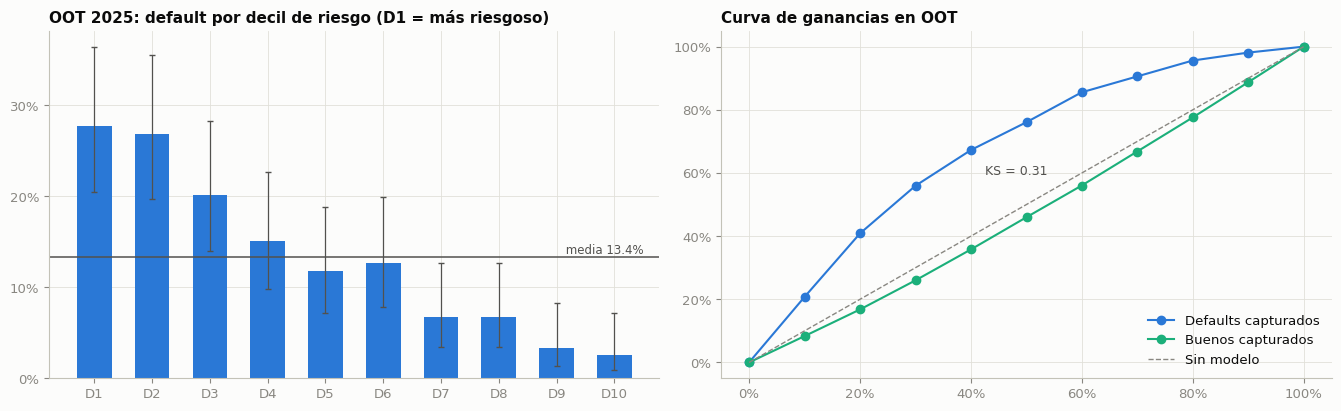

In [4]:
deciles = ev.decile_table(oot[T], pd_champion(oot))
display(deciles)
deciles.to_csv(cfg.TABLES / "validacion_deciles_oot.csv")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
x = np.arange(len(deciles))
barras_con_ic(axes[0], [f"D{i}" for i in deciles.index], deciles["default_rate"], deciles["ic_inf"], deciles["ic_sup"],
              BLUE, ancho=0.6, valores=False)
axes[0].axhline(oot[T].mean(), color=INK_2, lw=1.1)
axes[0].text(len(deciles) - 0.5, oot[T].mean(), f" media {oot[T].mean():.1%}", color=INK_2, fontsize=8.5, ha="right", va="bottom")
axes[0].set_xticks(x, [f"D{i}" for i in deciles.index]); pct_axis(axes[0])
axes[0].set_title("OOT 2025: default por decil de riesgo (D1 = más riesgoso)")
axes[1].plot(np.r_[0, deciles["poblacion_acum"]], np.r_[0, deciles["captura_malos_acum"]], marker="o", color=BLUE, label="Defaults capturados")
axes[1].plot(np.r_[0, deciles["poblacion_acum"]], np.r_[0, deciles["captura_buenos_acum"]], marker="o", color=AQUA, label="Buenos capturados")
axes[1].plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--", label="Sin modelo")
i_ks = int(np.argmax(deciles["ks_acumulado"].to_numpy()))
axes[1].annotate(f"KS = {deciles['ks_acumulado'].max():.2f}",
                 (deciles["poblacion_acum"].iloc[i_ks], deciles["captura_malos_acum"].iloc[i_ks]),
                 xytext=(10, -18), textcoords="offset points", fontsize=9, color=INK_2)
axes[1].set_title("Curva de ganancias en OOT"); axes[1].legend(loc="lower right")
pct_axis(axes[1]); pct_axis(axes[1], axis="x")
fig.tight_layout(); savefig(fig, "fig23_deciles_ganancias"); plt.show()

**Lectura.** Los tres deciles más riesgosos concentran el 56% de los defaults de 2025 con el 30% de la cartera (lift acumulado 1.7), y el decil más sano incumple 2.5% frente a 13.4% de la media (lift 0.19). El KS acumulado llega a 0.32 alrededor del 40% de la población: ese es el punto donde el corte separa mejor, y es consistente con la zona donde 6.9 ubica el rechazo.

## 3. Calibración: diagnóstico

In [5]:
calib = {s: ev.calibration_table(d[T], pd_champion(d), bins=8).assign(muestra=s) for s, d in muestras.items()}
display(pd.concat(calib.values()))
pd.concat(calib.values()).to_csv(cfg.TABLES / "validacion_calibracion_diagnostico.csv")
for s, d in muestras.items():
    m = ev.calibration_metrics(d[T], pd_champion(d))
    print(f"{s}: PD media {m['pd_media_predicha']:.1%} vs observado {m['default_observado']:.1%} | O/E {m['observado_sobre_predicho']:.2f}"
          f" | intercepto {m['calibracion_intercepto']:+.2f} | pendiente {m['calibracion_pendiente']:.2f} | ECE {m['ece']:.3f}")

,creditos,defaults,pd_predicha,default_observado,ic_inf,ic_sup,observado_sobre_predicho,dentro_del_ic,muestra
tramo_pd,,,,,,,,,
1,431,7,0.0217,0.0162,0.0079,0.0331,0.7497,True,DEV
2,430,17,0.0407,0.0395,0.0248,0.0624,0.9706,True,DEV
3,430,24,0.0552,0.0558,0.0378,0.0817,1.0108,True,DEV
4,431,34,0.0687,0.0789,0.0570,0.1082,1.1485,True,DEV
5,430,37,0.0894,0.0860,0.0631,0.1164,0.9620,True,DEV
6,430,48,0.1166,0.1116,0.0852,0.1449,0.9570,True,DEV
7,430,74,0.1642,0.1721,0.1394,0.2106,1.0479,True,DEV
8,431,110,0.2593,0.2552,0.2163,0.2984,0.9844,True,DEV
1,144,7,0.0214,0.0486,0.0237,0.0969,2.2714,False,VAL


DEV: PD media 10.2% vs observado 10.2% | O/E 1.00 | intercepto +0.00 | pendiente 1.00 | ECE 0.007
VAL: PD media 9.9% vs observado 14.0% | O/E 1.41 | intercepto -0.08 | pendiente 0.76 | ECE 0.041
OOT: PD media 10.2% vs observado 13.4% | O/E 1.31 | intercepto +0.20 | pendiente 0.93 | ECE 0.032


**Lectura.** El diagnóstico confirma lo que anticipó 6.4: el modelo **ordena bien pero subestima el nivel**. En DEV la calibración es correcta por construcción (O/E 1.00). En VAL predice 9.9% y se observa 14.0% (O/E 1.41) y en OOT predice 10.2% contra 13.4% (O/E 1.31). La recta de calibración tiene pendiente 0.76 en VAL: **no es un corrimiento paralelo**, así que corregir solo el intercepto dejaría mal calibradas las bandas altas.

## 4. Recalibración: Platt vs. isotónica

Las dos se **ajustan en VAL** (la muestra que 6.2 reservó para calibrar) y se prueban en **OOT**, que es la única forma honesta de saber si la corrección generaliza.

Platt: {'metodo': 'platt', 'intercepto': -0.08, 'pendiente': 0.758}


pd_media  observado  observado_sobre_predicho  brier    ece  pendiente   gini
metodo         muestra                                                                               
Sin recalibrar VAL        0.0990     0.1399                    1.4132 0.1169 0.0409     0.7582 0.3485
               OOT        0.1019     0.1337                    1.3125 0.1099 0.0318     0.9338 0.4239
Platt          VAL        0.1399     0.1399                    0.9996 0.1150 0.0215     0.9999 0.3485
               OOT        0.1426     0.1337                    0.9379 0.1087 0.0199     1.2317 0.4239
Isotónica      VAL        0.1399     0.1399                    1.0000 0.1139 0.0176     1.0001 0.3643
               OOT        0.1420     0.1337                    0.9417 0.1087 0.0150     1.1121 0.4064

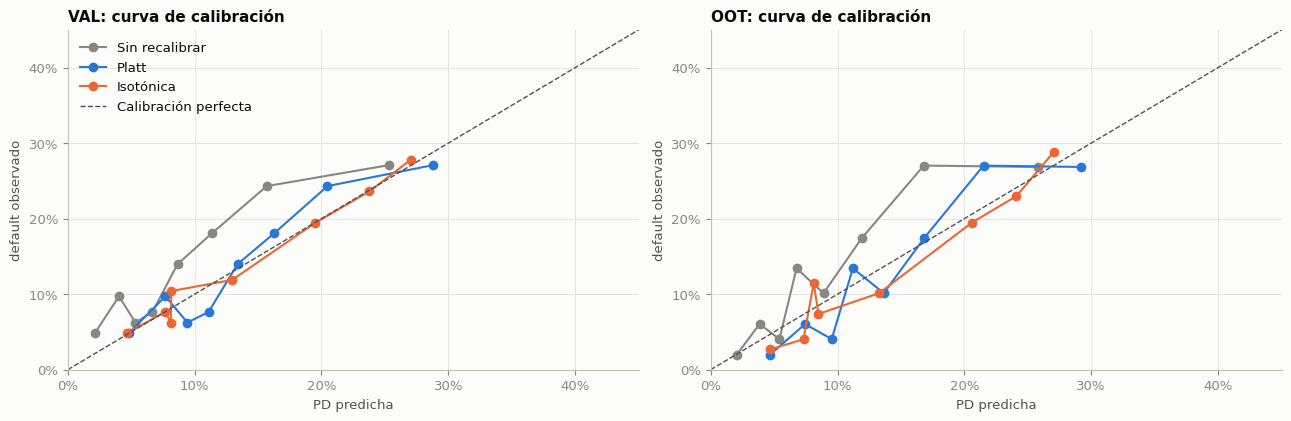

In [6]:
platt = ev.PlattCalibrator().fit(pd_champion(val), val[T])
isotonica = ev.IsotonicCalibrator().fit(pd_champion(val), val[T])
print("Platt:", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in platt.to_dict().items()})

filas = []
for nombre, f in [("Sin recalibrar", lambda p: p), ("Platt", platt.transform), ("Isotónica", isotonica.transform)]:
    for s in ["VAL", "OOT"]:
        d = muestras[s]
        p = f(pd_champion(d))
        m = ev.calibration_metrics(d[T], p)
        filas.append({"metodo": nombre, "muestra": s, "pd_media": m["pd_media_predicha"], "observado": m["default_observado"],
                      "observado_sobre_predicho": m["observado_sobre_predicho"], "brier": m["brier"], "ece": m["ece"],
                      "pendiente": m["calibracion_pendiente"], "gini": ev.discrimination(d[T], p)["gini"]})
recal = pd.DataFrame(filas).set_index(["metodo", "muestra"])
display(recal)
recal.to_csv(cfg.TABLES / "validacion_recalibracion.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, s in zip(axes, ["VAL", "OOT"]):
    d = muestras[s]
    for nombre, f, col in [("Sin recalibrar", lambda p: p, MUTED), ("Platt", platt.transform, BLUE),
                           ("Isotónica", isotonica.transform, ORANGE)]:
        t = ev.calibration_table(d[T], f(pd_champion(d)), bins=8)
        ax.plot(t["pd_predicha"], t["default_observado"], marker="o", color=col, label=nombre)
    lim = [0, 0.45]
    ax.plot(lim, lim, color=INK_2, lw=1, ls="--", label="Calibración perfecta")
    ax.set_xlim(lim); ax.set_ylim(lim); pct_axis(ax); pct_axis(ax, axis="x")
    ax.set_xlabel("PD predicha"); ax.set_ylabel("default observado")
    ax.set_title(f"{s}: curva de calibración")
axes[0].legend(loc="upper left")
fig.tight_layout(); savefig(fig, "fig24_calibracion"); plt.show()

**Decisión: Platt.** Las dos corrigen el nivel en VAL (O/E 1.00 por construcción) y las dos siguen razonables en OOT (O/E 0.94: ahora el modelo queda levemente **conservador**, que es el lado correcto para provisionar). La diferencia está en lo que cuesta cada una:

| Criterio | Platt | Isotónica |
|---|---|---|
| ECE en OOT | 0.020 | 0.015 |
| Gini en OOT | **0.424** (intacto) | 0.406 (−1.8 puntos) |
| Forma | Monótona estricta: no cambia el orden ni las bandas de score | Escalonada: crea empates y rompe el orden dentro de los tramos |
| Parámetros | 2, auditables e interpretables | Una función escalonada ajustada con 161 defaults |

La isotónica gana algo de error de calibración pero **sacrifica capacidad de ordenar y estabilidad**, justo lo que la política necesita para definir cortes y bandas. Se adopta **Platt (intercepto y pendiente)**, se guarda como artefacto versionado y se recalibra con la ventana más reciente cuando el monitoreo lo dispare.

## 5. Estabilidad

**Punto de operación de la política, ya con la PD recalibrada.** El corte de aprobación automática de 6.9 es una PD calibrada de 18%; así se comporta en OOT:

In [7]:
pd_cal_oot = platt.transform(pd_champion(oot))
print({k: round(v, 3) for k, v in ev.classification_metrics(oot[T], pd_cal_oot, cfg.PD_APPROVE_MAX).items()})
display(ev.confusion_frame(oot[T], pd_cal_oot, cfg.PD_APPROVE_MAX))

{'umbral_pd': 0.18, 'marcados': 309, 'precision': 0.259, 'recall': 0.503, 'f1': 0.342, 'exactitud': 0.741, 'vp': 80, 'fp': 229, 'fn': 79, 'vn': 801}


,Modelo: no marca,Modelo: marca riesgo
Bueno observado,801,229
Default observado,79,80


In [8]:
s_dev, s_val, s_oot = card.score(dev), card.score(val), card.score(oot)
psi_score = {"DEV -> VAL": validation.psi(pd.Series(s_dev), pd.Series(s_val)),
             "DEV -> OOT": validation.psi(pd.Series(s_dev), pd.Series(s_oot))}
psi_pd = {"DEV -> VAL": validation.psi(pd.Series(pd_champion(dev)), pd.Series(pd_champion(val))),
          "DEV -> OOT": validation.psi(pd.Series(pd_champion(dev)), pd.Series(pd_champion(oot)))}
print("PSI del score:", {k: round(v, 4) for k, v in psi_score.items()}, "| PSI de la PD:", {k: round(v, 4) for k, v in psi_pd.items()})
estab = pd.DataFrame({
    "psi_val": {v: validation.psi(dev[v], val[v]) for v in card.variables},
    "psi_oot": {v: validation.psi(dev[v], oot[v]) for v in card.variables},
    "gini_val": {v: abs(validation.gini(val[T], -card.binnings[v].transform(val[v]))) for v in card.variables},
    "gini_oot": {v: abs(validation.gini(oot[T], -card.binnings[v].transform(oot[v]))) for v in card.variables}})
display(estab)
estab.to_csv(cfg.TABLES / "validacion_estabilidad.csv")
gini_anio = pd.Series({a: validation.gini(g[T], pd_champion(g)) for a, g in fx.groupby(fx[cfg.DATE_COL].dt.year)})
print("Gini del champion por cosecha:", gini_anio.round(3).to_dict())

PSI del score: {'DEV -> VAL': 0.0047, 'DEV -> OOT': 0.0078} | PSI de la PD: {'DEV -> VAL': 0.0107, 'DEV -> OOT': 0.0103}


,psi_val,psi_oot,gini_val,gini_oot
bureau_score,0.0065,0.0114,0.3175,0.3893
dti_post,0.0088,0.0067,0.0833,0.1505
ahorro_sobre_monto,0.0111,0.0091,0.0763,0.0317


Gini del champion por cosecha: {2021: 0.487, 2022: 0.366, 2023: 0.464, 2024: 0.348, 2025: 0.424}


**Lectura.** El PSI del score es 0.005 hacia VAL y 0.008 hacia OOT, y el de las tres características del scorecard no pasa de 0.01: **la población que llega es la misma**. Lo que cambió es el riesgo a igual perfil, que es exactamente el diagnóstico de 6.4 y lo que arregla la recalibración. El Gini por cosecha (0.49, 0.37, 0.46, 0.35, 0.42) se mueve dentro de una banda que ya existía en desarrollo: sirve como referencia para el semáforo de monitoreo de 6.15, no como señal de deterioro.

## 6. Champion vs. Challenger en OOT

In [9]:
comp_oot = pd.DataFrame({
    n: {**ev.discrimination(oot[T], f(oot)), **{k: v for k, v in ev.calibration_metrics(oot[T], f(oot)).items()
                                                if k in ("brier", "observado_sobre_predicho")}}
    for n, f in [("Champion · scorecard", pd_champion), ("Challenger · LightGBM monótono", pd_challenger)]}).T
display(comp_oot)
dif = validation.paired_bootstrap_auc(oot[T], pd_challenger(oot), pd_champion(oot), n_boot=1000, seed=cfg.SEED)
print(f"OOT: AUC(challenger) - AUC(champion) = {dif['delta_auc']:+.4f} (IC 95%: {dif['ic_inf']:+.4f} a {dif['ic_sup']:+.4f})")
comp_oot.to_csv(cfg.TABLES / "validacion_champion_vs_challenger_oot.csv")

,auc,gini,ks,brier,observado_sobre_predicho
Champion · scorecard,0.7120,0.4239,0.3375,0.1099,1.3125
Challenger · LightGBM monótono,0.7343,0.4686,0.3556,0.1061,1.3227


OOT: AUC(challenger) - AUC(champion) = +0.0224 (IC 95%: -0.0016 a +0.0443)


**El challenger ordenó algo mejor en 2025, pero la diferencia no es concluyente.** El LightGBM monótono llega a Gini 0.469 contra 0.424 del champion; la diferencia de AUC es +0.022 con un intervalo de −0.002 a +0.044, que **incluye el cero**. Reportarlo importa por dos razones: el champion se eligió en 6.6 sin mirar el OOT, y esta es justamente la evidencia que el gobierno del modelo necesita para decidir si el challenger se promueve.

**Recomendación:** mantener el scorecard como champion (interpretable, calibrable, de sub-milisegundo y con explicación exacta) y dejar al challenger en seguimiento. Si en dos cosechas seguidas la diferencia se sostiene y su intervalo excluye el cero, se promueve con el mismo veto de fairness y sujeto a SHAP y a la validación independiente.

## 7. Artefactos y trazabilidad

In [10]:
import json as _json
artefacto = {"modelo": "scorecard_pd_v1", "calibrador": platt.to_dict(), "ajustado_en": "VAL 2024",
             "pd_media_recalibrada_oot": float(platt.transform(pd_champion(oot)).mean()),
             "default_observado_oot": float(oot[T].mean()),
             "nota": "PD de producción = Platt(PD del scorecard). Recalibrar cuando el monitoreo lo dispare."}
(cfg.ROOT / "models" / "calibrador_platt_v1.json").write_text(_json.dumps(artefacto, ensure_ascii=False, indent=2), encoding="utf-8")
print(_json.dumps(artefacto, ensure_ascii=False, indent=2))

{
  "modelo": "scorecard_pd_v1",
  "calibrador": {
    "metodo": "platt",
    "intercepto": -0.08003522819266515,
    "pendiente": 0.7582465515344059
  },
  "ajustado_en": "VAL 2024",
  "pd_media_recalibrada_oot": 0.14257273524349046,
  "default_observado_oot": 0.13372582001682085,
  "nota": "PD de producción = Platt(PD del scorecard). Recalibrar cuando el monitoreo lo dispare."
}


| Requisito 6.7 | Dónde |
|---|---|
| AUC/ROC, Gini, KS, Precision, Recall, F1, matriz de confusión, Brier, Lift/Gains y deciles | §1 y §2 · `validacion_metricas.csv`, `validacion_deciles_oot.csv` · `fig23` |
| Performance en Development, Validation y OOT | §1 · las tres muestras en la misma tabla |
| Curva de calibración y PD predicha vs. observada por bandas | §3 y §4 · `fig24` · `validacion_calibracion_diagnostico.csv` |
| Método de recalibración justificado y comparación antes/después | §4 · Platt vs. isotónica, ajuste en VAL y prueba en OOT · `validacion_recalibracion.csv` |
| Estabilidad con PSI | §5 · `validacion_estabilidad.csv` |